In [26]:
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2

In [30]:
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [16]:
data = load_iris()
X, y = data.data, data.target
labels = data.target_names

In [17]:
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [18]:
# Enter your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
pipeline.fit(X_train, y_train)

# Measure the pipeline accuracy on the test data
test_score=pipeline.score(X_test, y_test)

print(f"{test_score:.3f}")



0.900


In [20]:
y_pred = pipeline.predict(X_test)

Generate the confusion matrix for KNN model and plot it.

[]

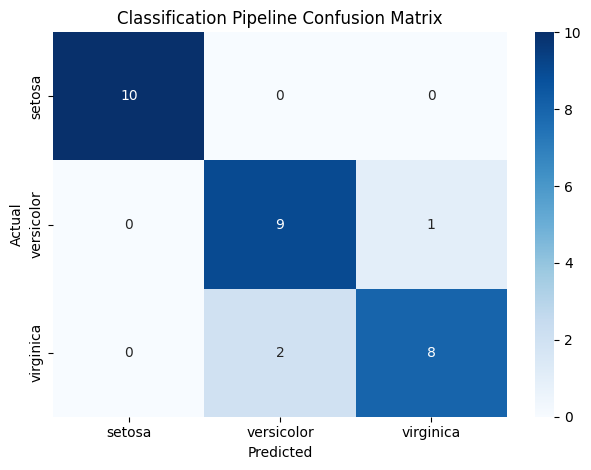

In [21]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.plot()



The model incorectly classified two viginica irises as versicolor, and one versicolor as virginica. Not bad, only three classification errors out of 30 irises on our first attempt!

 It would be a mistake to keep running the model over and over again with different hyperparamters to find the best one.
 You would effectively be overfiiting the model to your test data set.
 The correct way to handle this tuning is to use cross validation.

In [22]:
# make a pipeline without specifying any parameters yet
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

In [33]:
# Hyperparameter search grid for numbers of PCA components and KNN neighbors
param_grid = {
    'pca__n_components': [2, 3],
    'knn__n_neighbors': [3, 5, 7]
}

 To ensure the target is stratified, we can use scikit-learn's StratifiedKFold cross-validation class.

In [34]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
best_model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=3)

In [38]:
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END knn__n_neighbors=3, pca__n_components=2;, score=0.875 total time=   0.0s
[CV 2/5] END knn__n_neighbors=3, pca__n_components=2;, score=0.917 total time=   0.0s
[CV 3/5] END knn__n_neighbors=3, pca__n_components=2;, score=0.917 total time=   0.0s
[CV 4/5] END knn__n_neighbors=3, pca__n_components=2;, score=0.875 total time=   0.0s
[CV 5/5] END knn__n_neighbors=3, pca__n_components=2;, score=0.833 total time=   0.0s
[CV 1/5] END knn__n_neighbors=3, pca__n_components=3;, score=0.958 total time=   0.0s
[CV 2/5] END knn__n_neighbors=3, pca__n_components=3;, score=1.000 total time=   0.0s
[CV 3/5] END knn__n_neighbors=3, pca__n_components=3;, score=0.958 total time=   0.0s
[CV 4/5] END knn__n_neighbors=3, pca__n_components=3;, score=0.958 total time=   0.0s
[CV 5/5] END knn__n_neighbors=3, pca__n_components=3;, score=0.958 total time=   0.0s
[CV 1/5] END knn__n_neighbors=5, pca__n_components=2;, score=0.875 total time=  

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scalar', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=3)

In [39]:
test_score = best_model.score(X_test, y_test)
print(f"{test_score:.3f}")

0.933


In [40]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}

[]

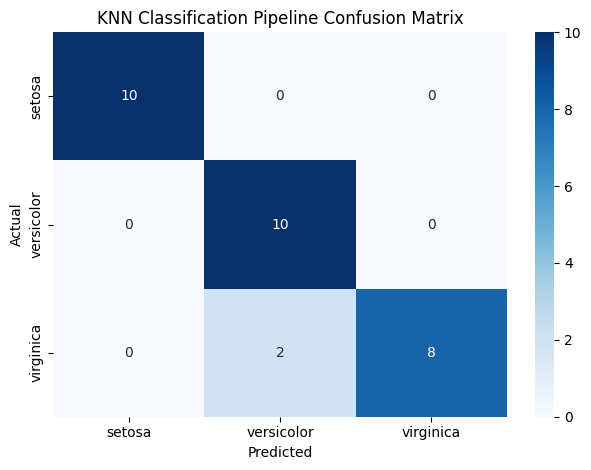

In [41]:
y_pred= best_model.predict(X_test)

# Generate the confusion matrix for KNN
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title('KNN Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.plot()